In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score

In [2]:
df = pd.read_excel("воронка.xlsx")

In [3]:
df = df.rename(columns={
    "Viewed": "viewed",
    "Add-to-Cart": "add_to_cart",
    "Orders": "orders",
    "Add-to-Cart Conversion (%)": "add_to_cart_conversion",
    "Order Conversion (%)": "order_conversion",
    "Add-to-Favorites": "add_to_favorites",
    "актуальные охваты": "reach",
    "продукт": "product",
    "CPM": "cpm",
    "затраты": "cost",
    "формат": "format",
    "месяц": "month",
    "платформа": "platform"
})

In [4]:
text_cols = ["product", "format", "month", "platform"]

for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "nan": np.nan,
            "none": np.nan,
            "": np.nan,
            "-": np.nan
        })
    )

In [5]:
num_cols = [
    "viewed",
    "add_to_cart",
    "orders",
    "add_to_cart_conversion",
    "order_conversion",
    "add_to_favorites",
    "reach",
    "cpm",
    "cost"
]

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace(",", ".", regex=False)
    )

    df[col] = pd.to_numeric(df[col], errors="coerce")

In [6]:
critical_cols = [
    "viewed",
    "add_to_cart",
    "reach",
    "cost"
]

df = df[df[critical_cols].isnull().sum(axis=1) < 3]

In [7]:
for col in [
    "viewed",
    "add_to_cart",
    "add_to_favorites",
    "reach",
    "cpm",
    "cost"
]:
    df[col] = df[col].fillna(df[col].median())

In [8]:
df["view_rate"] = df["viewed"] / (df["reach"] + 1)

df["cart_rate"] = (
    df["add_to_cart"] / (df["viewed"] + 1)
)

df["favorite_rate"] = (
    df["add_to_favorites"] / (df["viewed"] + 1)
)

In [9]:
product_freq = df["product"].value_counts(normalize=True)

df["product_freq"] = df["product"].map(product_freq)

df["product_freq"] = df["product_freq"].fillna(
    df["product_freq"].median()
)

In [10]:
df = df[df["orders"] <= 150]
feature_cols = [
    "viewed",
    "add_to_cart",
    "add_to_favorites",
    "reach",
    "cpm",
    "cost",
    "view_rate",
    "cart_rate",
    "favorite_rate",
    "product_freq",
    "format",
    "month",
    "platform"
]

X = df[feature_cols]

y = df["orders"]

In [11]:
numeric_features = [
    "viewed",
    "add_to_cart",
    "add_to_favorites",
    "reach",
    "cpm",
    "cost",
    "view_rate",
    "cart_rate",
    "favorite_rate",
    "product_freq"
]

categorical_features = [
    "format",
    "month",
    "platform"
]

In [12]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),

    ("regressor", RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

In [15]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(
    y_test,
    y_pred
)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

MAE:  6.7126
RMSE: 134.1464
R2:   0.5772


In [16]:
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = model.named_steps[
    "regressor"
].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(20))

                   feature  importance
0              num__viewed    0.577680
1         num__add_to_cart    0.178249
2    num__add_to_favorites    0.055529
3               num__reach    0.043318
6           num__view_rate    0.028675
4                 num__cpm    0.023151
5                num__cost    0.019546
9        num__product_freq    0.017703
7           num__cart_rate    0.015936
8       num__favorite_rate    0.011878
10        cat__format_влог    0.008929
18         cat__month_март    0.005280
19      cat__month_февраль    0.005249
20       cat__month_январь    0.003325
12  cat__format_интеграция    0.001886
17      cat__month_декабрь    0.001521
13       cat__format_обзор    0.001397
16       cat__format_тутор    0.000376
24    cat__platform_тикток    0.000255
23        cat__platform_тг    0.000100


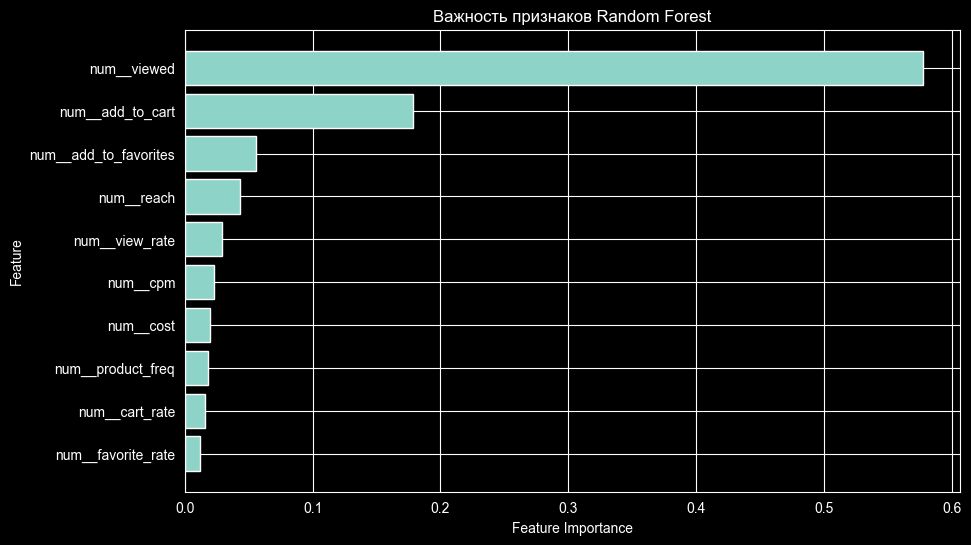

In [17]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['feature'],
    top_features['importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.title('Важность признаков Random Forest')

plt.gca().invert_yaxis()

plt.show()

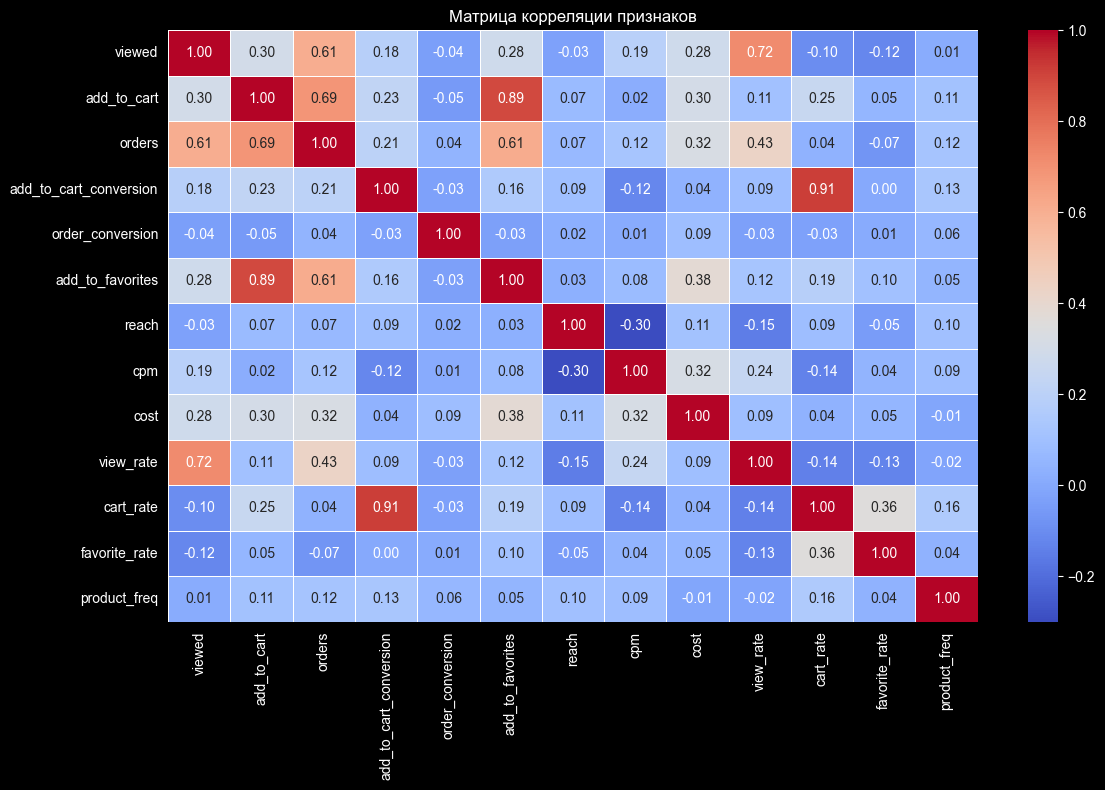

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# оставляем только числовые столбцы
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12, 8))
corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Матрица корреляции признаков")
plt.tight_layout()
plt.show()

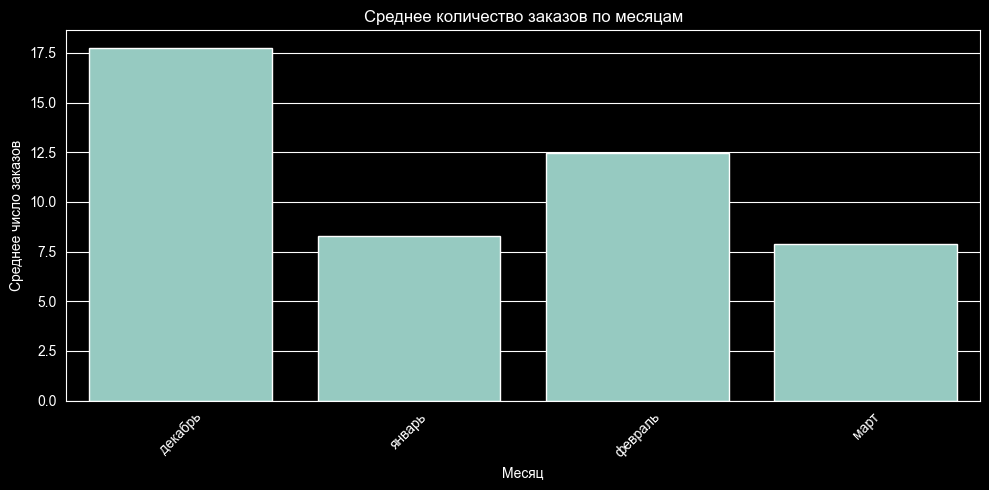

In [19]:
month_order = [
    "декабрь","январь", "февраль", "март"
]
# приводим месяц к упорядоченной категориальной переменной
df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)
# считаем среднее количество заказов по месяцам
month_orders = df.groupby("month", observed=False)["orders"].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=month_orders, x="month", y="orders")

plt.title("Среднее количество заказов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Среднее число заказов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

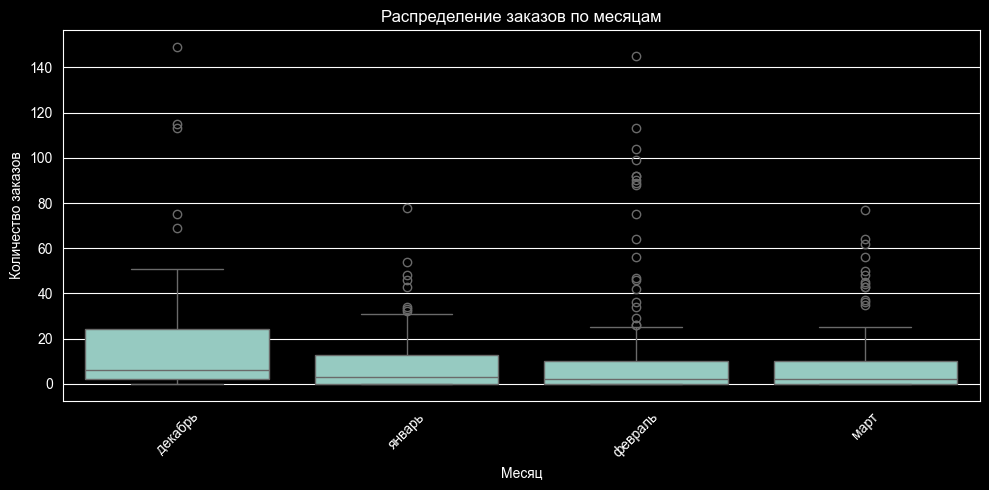

In [20]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="month", y="orders", order=month_order)

plt.title("Распределение заказов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

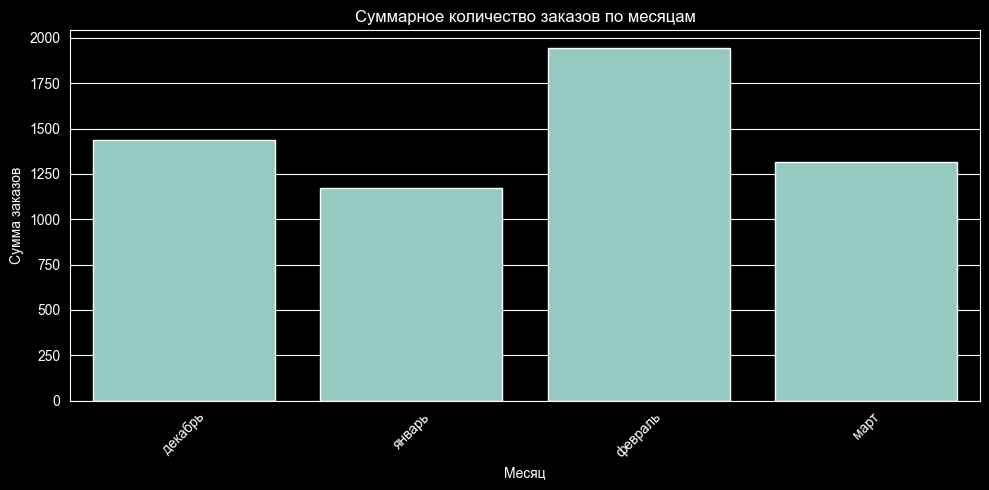

In [21]:
month_orders_sum = df.groupby("month", observed=False)["orders"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=month_orders_sum, x="month", y="orders")

plt.title("Суммарное количество заказов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Сумма заказов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
def predict_orders(
    model,
    viewed,
    add_to_cart,
    add_to_favorites,
    reach,
    cpm,
    cost,
    product_freq,
    format_,
    month,
    platform
):
    """
    Прогноз количества заказов по заданным признакам.
    model — уже обученная модель Pipeline (например, RandomForestRegressor + preprocessor)
    """
    # Собираем один объект в DataFrame
    input_data = pd.DataFrame([{
        "viewed": viewed,
        "add_to_cart": add_to_cart,
        "add_to_favorites": add_to_favorites,
        "reach": reach,
        "cpm": cpm,
        "cost": cost,
        "product_freq": product_freq,
        "format": format_,
        "month": month,
        "platform": platform
    }])
    input_data["view_rate"] = input_data["viewed"] / (input_data["reach"] + 1)
    input_data["cart_rate"] = input_data["add_to_cart"] / (input_data["viewed"] + 1)
    input_data["favorite_rate"] = input_data["add_to_favorites"] / (input_data["viewed"] + 1)

    predicted_orders = model.predict(input_data)[0]

    return predicted_orders

In [23]:
pred = predict_orders(
    model=model,
    viewed=10000,
    add_to_cart=120,
    add_to_favorites=45,
    reach=50000,
    cpm=6000,
    cost=45000,
    product_freq=0.08,
    format_="обзор",
    month="март",
    platform="тикток"
)

print("Прогноз заказов:", pred)

Прогноз заказов: 49.627945767195754


In [24]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

# параметры для перебора
param_grid = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__max_depth": [5, 8, 10, None],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__max_features": ["sqrt", "log2", None]
}

# кросс-валидация
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучший CV R2:", grid_search.best_score_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Лучшие параметры: {'regressor__max_depth': 10, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 100}
Лучший CV R2: 0.6768824260089574


In [27]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print("R2 по фолдам:", scores)
print("Средний R2:", scores.mean())
print("Std:", scores.std())

R2 по фолдам: [0.59631447 0.50387196 0.75624515 0.66246185 0.73232568]
Средний R2: 0.6502438246071229
Std: 0.09214780621635456
